Mahan Madani - 830504035

## Table of Contents

- [Import Libraries and Configs](#import-libraries-and-configs)
- [Datasets and Dataloader](#datasets-and-dataloaders)
- [Find and Index Caption CLIP Embeddings Using FAISS](#find-and-index-caption-clip-embeddings-using-faiss)
- [Update Train and Test Metadata Files](#update-train-and-test-metadata-files)
- [Similar Caption Retrieval Sample](#similar-caption-retrieval-sample)

## Import libraries and Configs

In [1]:
import os
import json
import faiss
import torch
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image
from torch.utils.data import DataLoader
from transformers import CLIPTokenizerFast, CLIPImageProcessorFast

In [2]:
from Modules.config import (TRAIN_IMAGE_DIR,
                            TRAIN_CAPTIONS_PATH,
                            TEST_IMAGE_DIR,
                            TEST_CAPTIONS_PATH,
                            FAISS_CAPTION_PATH,
                            TRAIN_METADATA_PATH,
                            TEST_METADATA_PATH,
                            CAPTION_METADATA_PATH,
                            CLIP_MODEL_NAME)

from Modules.retrieval_module import Retriever
from Modules.datasets import Flickr30kCaptionDataset, CLIPCaptionDataCollator, Flickr30kDataset, CLIPImageDataCollator
from Modules.embedding_module import Embedder

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

## Datasets and Dataloaders

Place the flickr30k dataset in the dataset folder and run the data_preprocess notebook to split it into train-test subsets.

In [4]:
train_dataset = Flickr30kCaptionDataset(TRAIN_CAPTIONS_PATH)
test_dataset  = Flickr30kCaptionDataset(TEST_CAPTIONS_PATH)

tokenizer = CLIPTokenizerFast.from_pretrained(CLIP_MODEL_NAME, local_files_only=True)
collator = CLIPCaptionDataCollator(tokenizer, DEVICE)

BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collator)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collator)

## Find and Index Caption CLIP Embeddings Using FAISS

In [5]:
embedder = Embedder(model_name=CLIP_MODEL_NAME, use_local_files=True, device=DEVICE)
faiss_caption_index = faiss.IndexFlatIP(embedder.embedding_dim)  # use cosine similarity

In [11]:
caption_metadata = {}
caption_index = 0

In [ ]:
loader = tqdm(train_loader, desc="Extracting CLIP embeddings")

for batch in loader:
    input_ids = batch.get('input_ids')
    attention_mask = batch.get('attention_mask')
    captions = batch.get('captions')
    image_names = batch.get('image_names')
    
    embeddings = embedder.get_text_embedding(input_ids, attention_mask)
    faiss_caption_index.add(embeddings)
    
    for i in range(len(captions)):
        caption_metadata[caption_index] = {
            "image_name": image_names[i],
            "caption": captions[i],
        }
        caption_index += 1

Extracting CLIP embeddings: 100%|██████████| 4810/4810 [00:20<00:00, 235.54it/s]


In [12]:
faiss.write_index(faiss_caption_index, FAISS_CAPTION_PATH)
print(f"Indexed {faiss_caption_index.ntotal} captions")

Indexed 153915 captions


In [13]:
with open(CAPTION_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(caption_metadata, f, indent=2, ensure_ascii=False)

## Update Train and Test Metadata Files

In [34]:
retriever_caption = Retriever(metadata_path=CAPTION_METADATA_PATH, faiss_path=FAISS_CAPTION_PATH)

In [ ]:
train_dataset = Flickr30kDataset(TRAIN_IMAGE_DIR, TRAIN_CAPTIONS_PATH)
test_dataset  = Flickr30kDataset(TEST_IMAGE_DIR, TEST_CAPTIONS_PATH)

processor = CLIPImageProcessorFast.from_pretrained(CLIP_MODEL_NAME, local_files_only=True)
collator = CLIPImageDataCollator(processor, DEVICE)

BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collator)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collator)

In [36]:
with open(TRAIN_METADATA_PATH, "r", encoding="utf-8") as f:
    train_metadata = json.load(f)
    
with open(TEST_METADATA_PATH, "r", encoding="utf-8") as f:
    test_metadata = json.load(f)
    
train_index = 0
test_index = 0

In [37]:
loader = tqdm(train_loader, desc="Finding similar captions")

for batch in loader:
    images = batch['pixel_values'].to(DEVICE) # shape [B, 3, W, H]
    image_names = batch['image_names']
    
    embeddings = embedder.get_image_embedding(images)
    similar_captions_data = retriever_caption.retrieve_similar_from_metadata(embeddings, k=10)

    for i in range(len(images)):
        similar_captions = []
        for caption_data in similar_captions_data[i]:
            if caption_data['image_name'] != image_names[i]:
                similar_captions.append(caption_data['caption'])
                 
                if len(similar_captions) >= 5:
                    break
                
        train_metadata[str(train_index)].update({
            "similar_captions": similar_captions
        })
        train_index += 1

Finding similar captions: 100%|██████████| 962/962 [04:26<00:00,  3.62it/s]


In [31]:
loader = tqdm(test_loader, desc="Finding similar captions")

for batch in loader:
    images = batch['pixel_values'].to(DEVICE) # shape [B, 3, W, H]
    image_names = batch['image_names']
    
    embeddings = embedder.get_image_embedding(images)
    similar_captions_data = retriever_caption.retrieve_similar_from_metadata(embeddings, k=5)

    for i in range(len(images)):
        similar_captions = []
        for caption_data in similar_captions_data[i]:
            similar_captions.append(caption_data['caption'])

        test_metadata[str(test_index)].update({
            "similar_captions": similar_captions
        })
        test_index += 1

Finding similar captions: 100%|██████████| 32/32 [00:08<00:00,  3.83it/s]


Save JSON Metadata

In [ ]:
with open(TRAIN_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(train_metadata, f, indent=2, ensure_ascii=False)
    
with open(TEST_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(test_metadata, f, indent=2, ensure_ascii=False)

## Similar Caption Retrieval Sample

In [16]:
from Modules.utils import display_image

In [11]:
test_dataset  = Flickr30kDataset(TEST_IMAGE_DIR,  TEST_CAPTIONS_PATH)

processor = CLIPImageProcessorFast.from_pretrained(CLIP_MODEL_NAME)
collator = CLIPImageDataCollator(processor, DEVICE)

BATCH_SIZE = 32
NUM_WORKERS = 0

test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collator)

In [12]:
caption_retriever = Retriever(faiss_path=FAISS_CAPTION_PATH, metadata_path=CAPTION_METADATA_PATH)

In [ ]:
k = 5
sample_idx = [1, 112, 501, 777, 910]
pixel_values = collator([test_dataset[idx] for idx in sample_idx])['pixel_values']

embedding = embedder.get_image_embedding(pixel_values)
similar_captions = caption_retriever.retrieve_similar_from_metadata(embedding, key='caption', k=k)

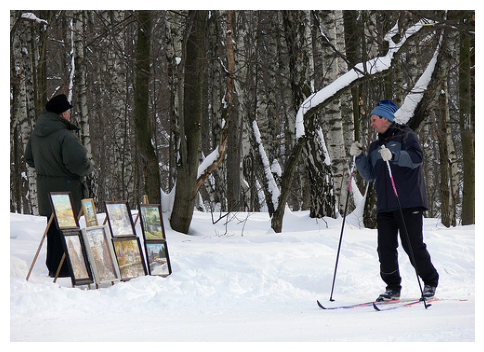

Ground Truth captions:
A person wearing skis looking at framed pictures set up in the snow .
A man in a hat is displaying pictures next to a skier in a blue hat .
A man skis past another man displaying paintings in the snow .
A skier looks at framed pictures in the snow next to trees .
Man on skis looking at artwork for sale in the snow

Similar captions:
Two men are skiing in the snow in a wooded area .
A man wearing a short-sleeved blue shirt and carrying a blue backpack while using snow walking sticks treks through the snow with a woman wearing a long-sleeved blue shirt and black pants also using snow walking sticks .
A man in brown and black is snowshoeing in a race .
A person walks up a snowy hill with skis on his or her back .
A man wearing snowshoes is walking up a hill as another person walks nearby him .


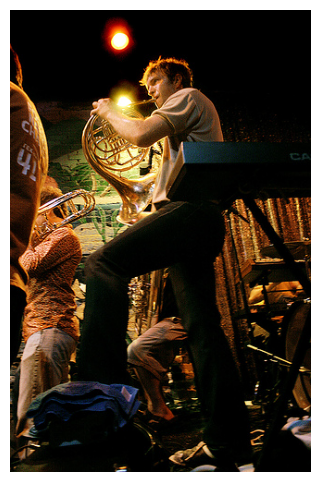

Ground Truth captions:
A young man in a group band playing a French Horn  with other musicians all around and large gold drapery in the background .
A young white man  wearing dark pants and a light colored t-shirt playing a french horn in a band .
A young French horn player rehearses with his orchestra .
Man performing  playing an instrument for a crowd .
a man is playing an instrument in a band

Similar captions:
A man with a microphone reads from a piece of paper as he stands in front of two men holding tubas .
A band on stage playing instruments like trumpets  trombones  french horns and violins while one of the men sings into a microphone .
A man plays the french horn as his pianist plays the supporting melody on stage .
A guy in a brown t-shirt and white pants is playing a horn .
A singer kneels with his microphone while a drummer plays in the background .


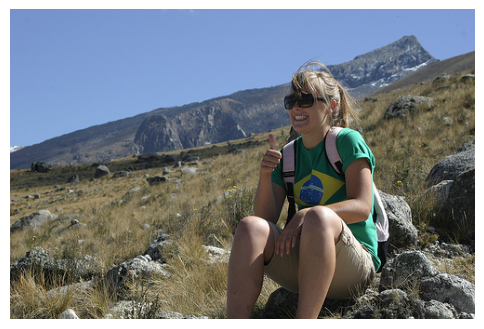

Ground Truth captions:
A girl with long blond-hair in the middle of nowhere with mountains in the background wearing a shirt from Argentina .
A young woman in a green t-shirt gives the thumbs up on a mountain .
A woman in sunglasses is smiling as she sits on top of some rocks .
A girl in a green shirt sitting on a rock in the wilderness .
A girl is sitting on the side of a mountain .

Similar captions:
A blond woman with a backpack is smiling in an outdoor setting .
A girl wearing a light blue t-shirt and pink and brown backpack has her hand on top of her blond-hair  as she is looking at mountains covered in trees and bushes .
A blond-hair boy in short  short-sleeve shirt and sandals in overlooking a snowcapped mountain .
A woman wearing short sleeves and sunglasses is backpacking up a snowy mountain cliff .
A woman in shorts and a green hoodie  at an observation point along a trail  overlooking the mountains below .


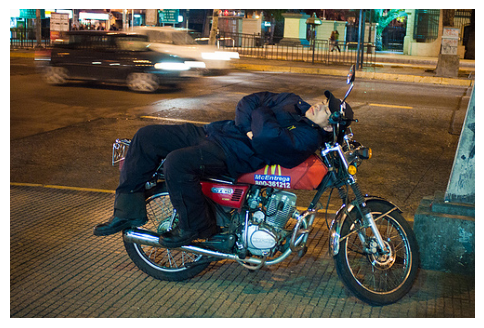

Ground Truth captions:
young man who is just tired of waiting for someone or needs some sleep before he travels on wit his bike .
A man sleeps on top of his motorcycle next to a busy street .
The man wearing all black is asleep on his red motorcycle .
A local man finds some time to take a nap on his chopper .
A man wearing a hat is sleeping on his motorcycle .

Similar captions:
A man in a red shirt is taking a nap on one of the motorcycles near him .
A man asleep while leaning on a bicycle .
A tired man is sleeping on his motorcycle on the side of the road .
A man is resting next to his upside down bicycle taking his glove off .
A male is resting his eyes on a bike .


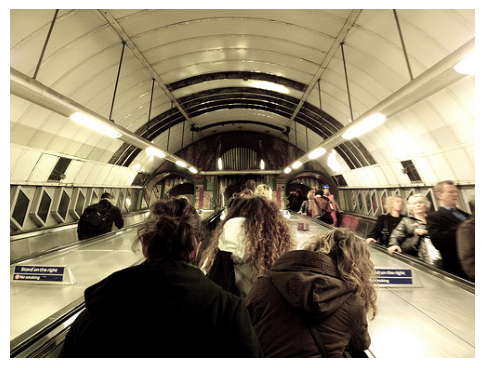

Ground Truth captions:
A group of people is traveling through a terminal with moving walkways .
Crowds of people are riding escalators up and down in a large tunnel .
People at a terminal are on an elevator packed with others .
A group of people stand on a moving sidewalk .
A group of people going up an escalator .

Similar captions:
People stand on a train platform underground .
The Oxford Circus Station has many visitors right beside the subway .
People waiting for a train on the underground platform of an urban metro system .
Several people stand in a subway tunnel .
A subway tunnel with people around it


In [21]:
for i, idx in enumerate(sample_idx):
    display_image(test_dataset[idx]['image'])
    print("Ground Truth captions:")
    print(*test_dataset[idx]['captions'], sep='\n', end='\n\n')
    
    print("Similar captions:")
    print(*similar_captions[i], sep='\n', end='\n')